# Plot Spects for Match vs Mismatch Trials

For Load-2 models — here, taking out normalization


In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
import os
import sys
import importlib
import scipy.io

# import utils path
sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import spect_utils as su 
from bootstrap_method import *

## Load IPSCs, plot spects and band powers

In [2]:
task_load = 2
n_neurons = 400
delay = 50

proj_dir = '/home/nuttidalab/Documents/spikeRNN/'
ipsc_dir = proj_dir + f'models/letters/load_{task_load}/IPSCs/'
model_dir = proj_dir + f'models/letters/load_{task_load}/'

# get all model IPSC files and model files
model_fnames = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(f'Found {len(model_fnames)} model files')

Found 30 model files


## testing on 1 model first

### Include all of baseline

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)


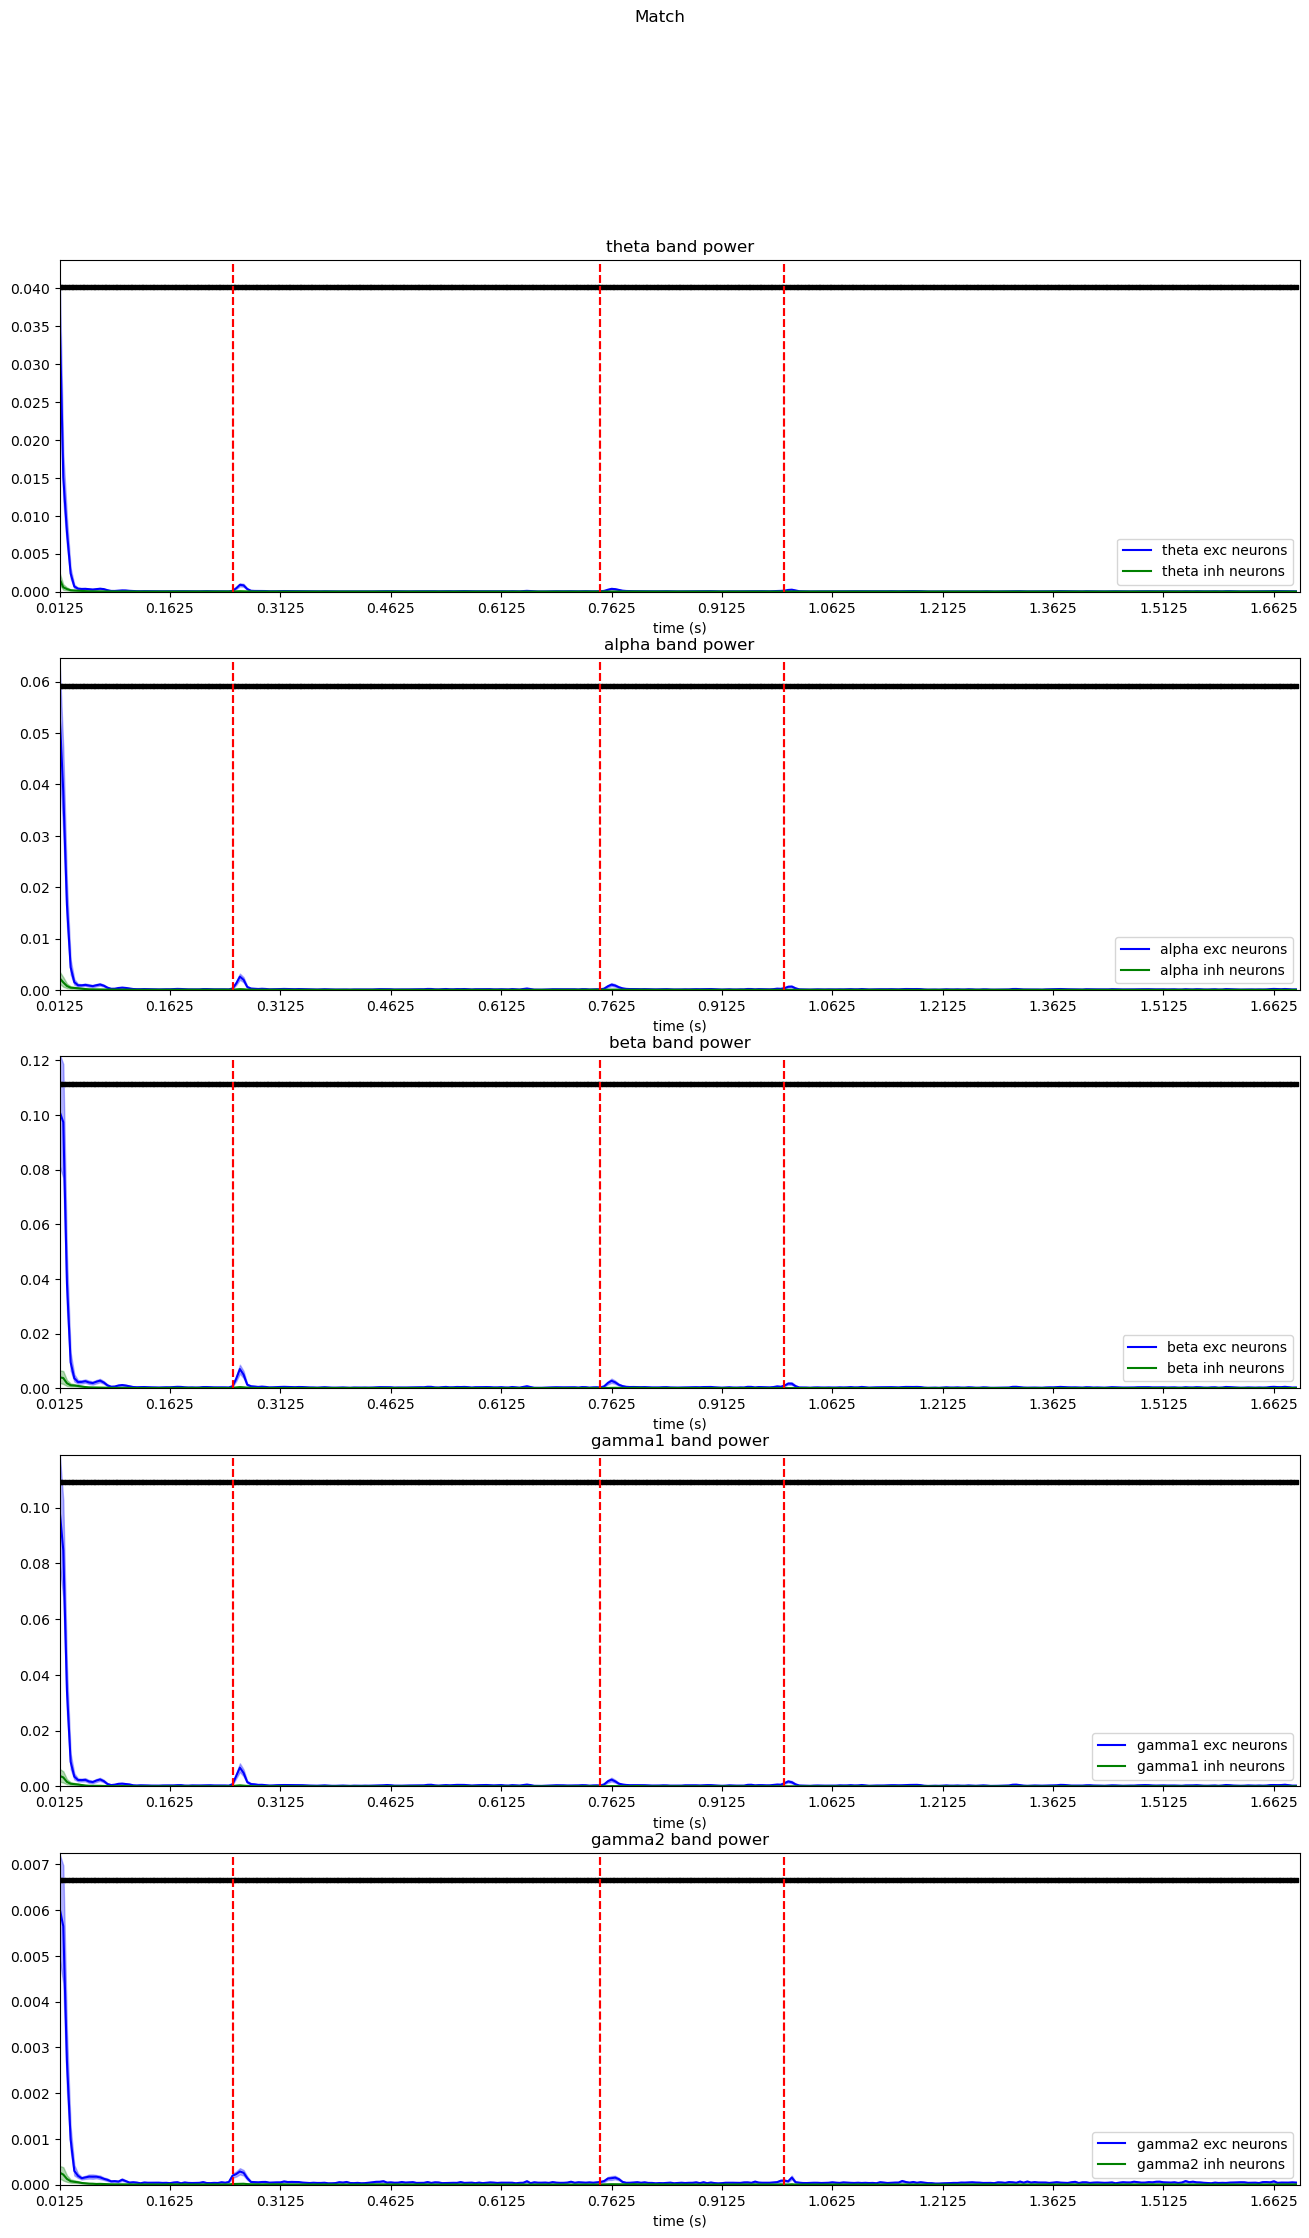

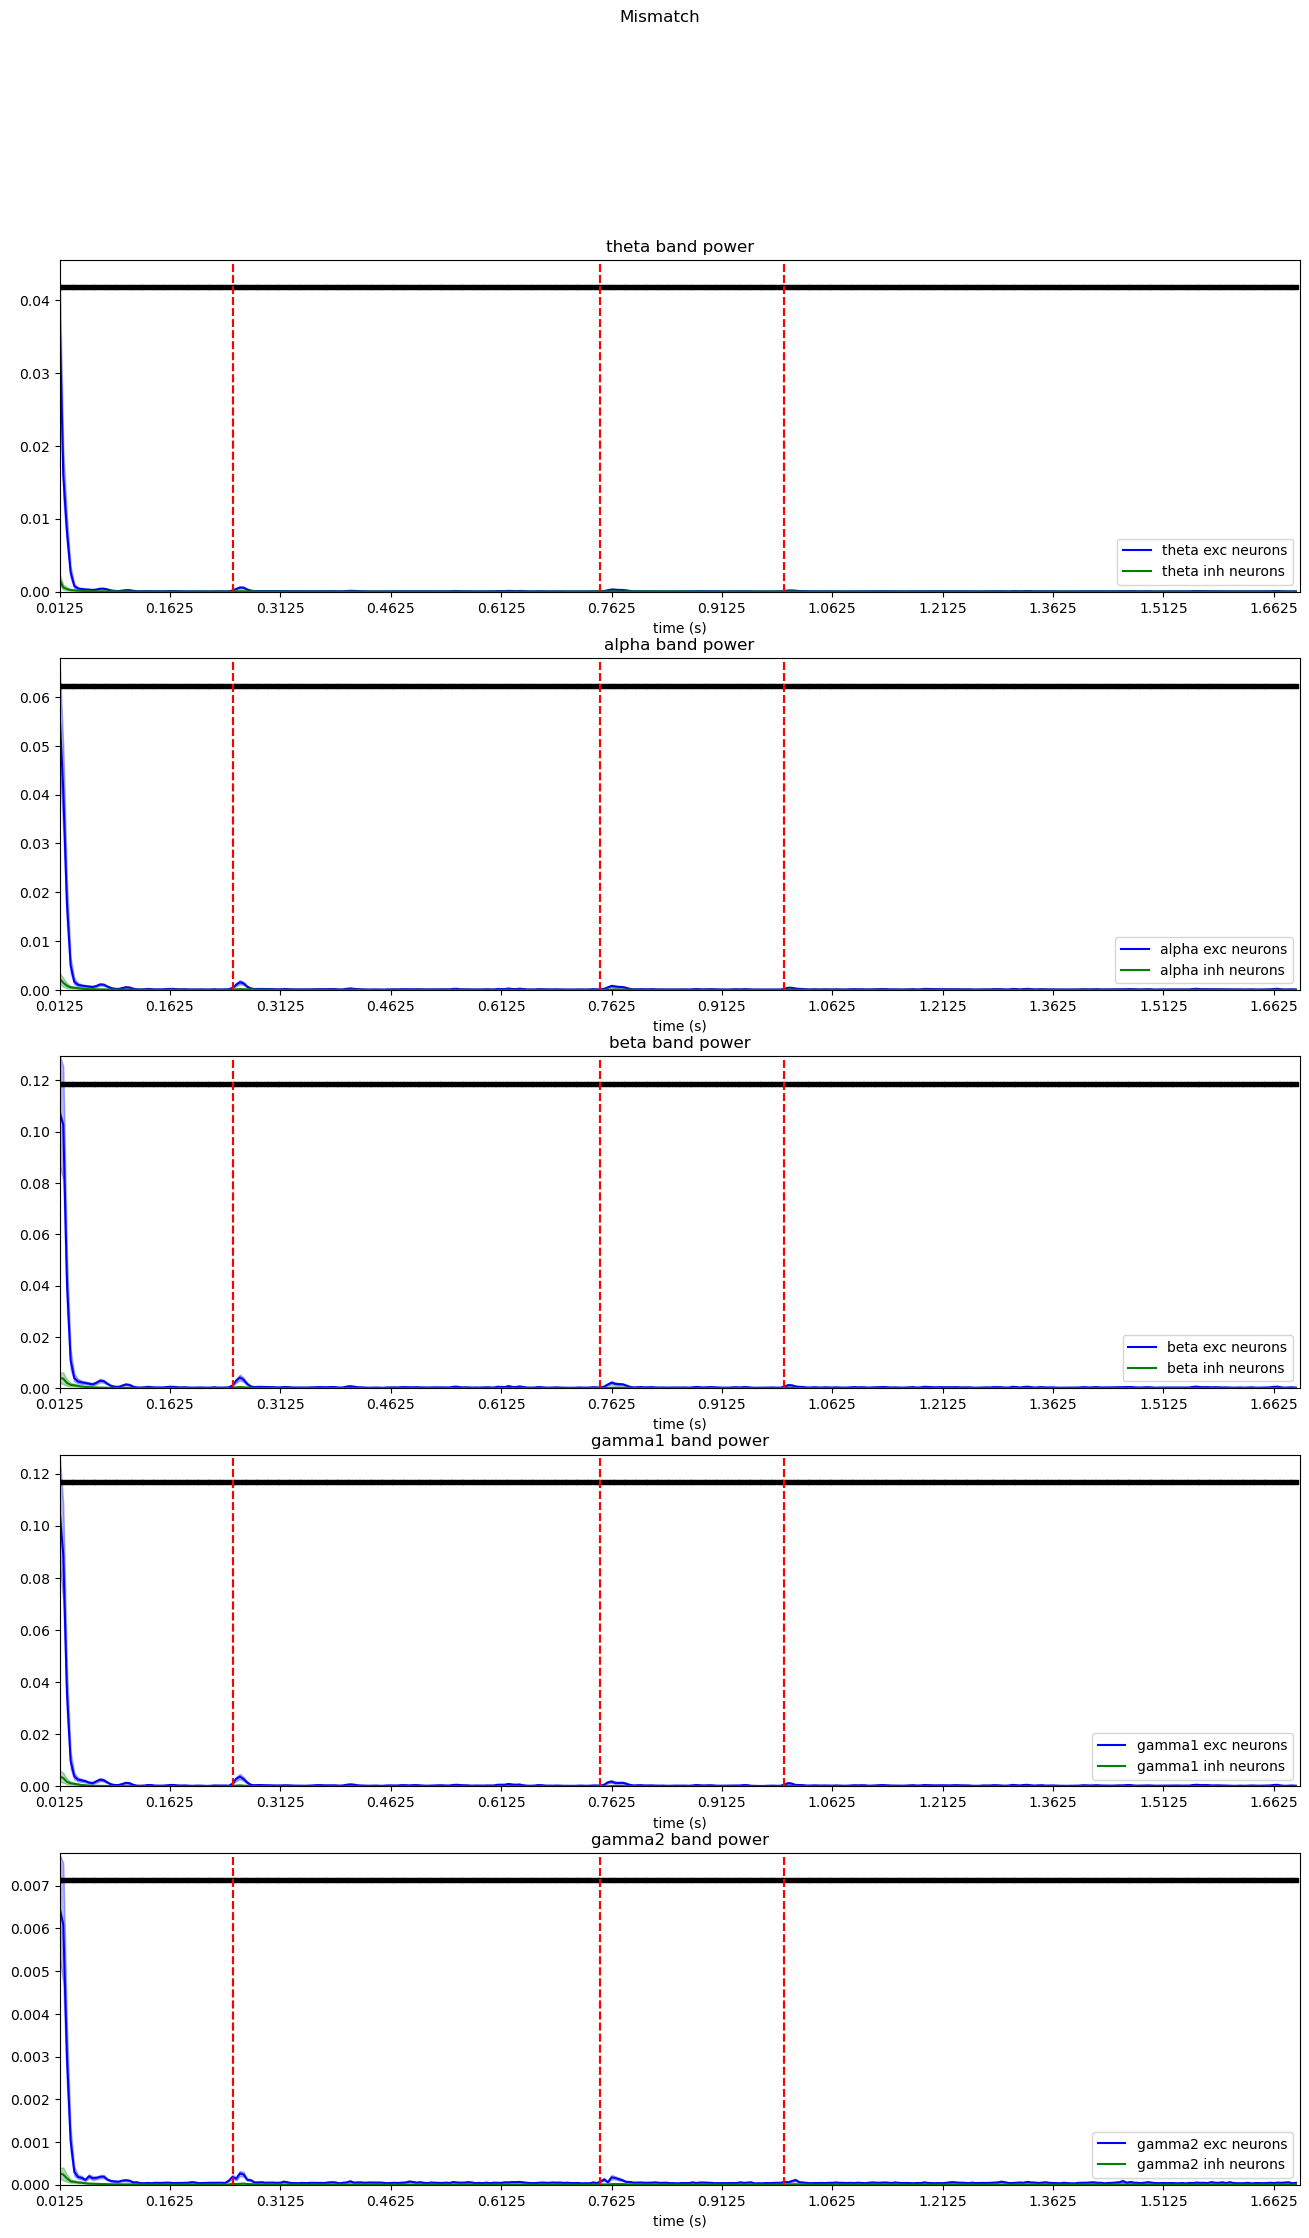

In [4]:
# plot band powers, including all of baseline

importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_match[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Match',
                  p_sig = 0.05, band_range = [], time_range = [])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_mismatch[exc_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Mismatch',
                  p_sig = 0.05, band_range = [], time_range = [])

    
    break
    
    

### Plot spects

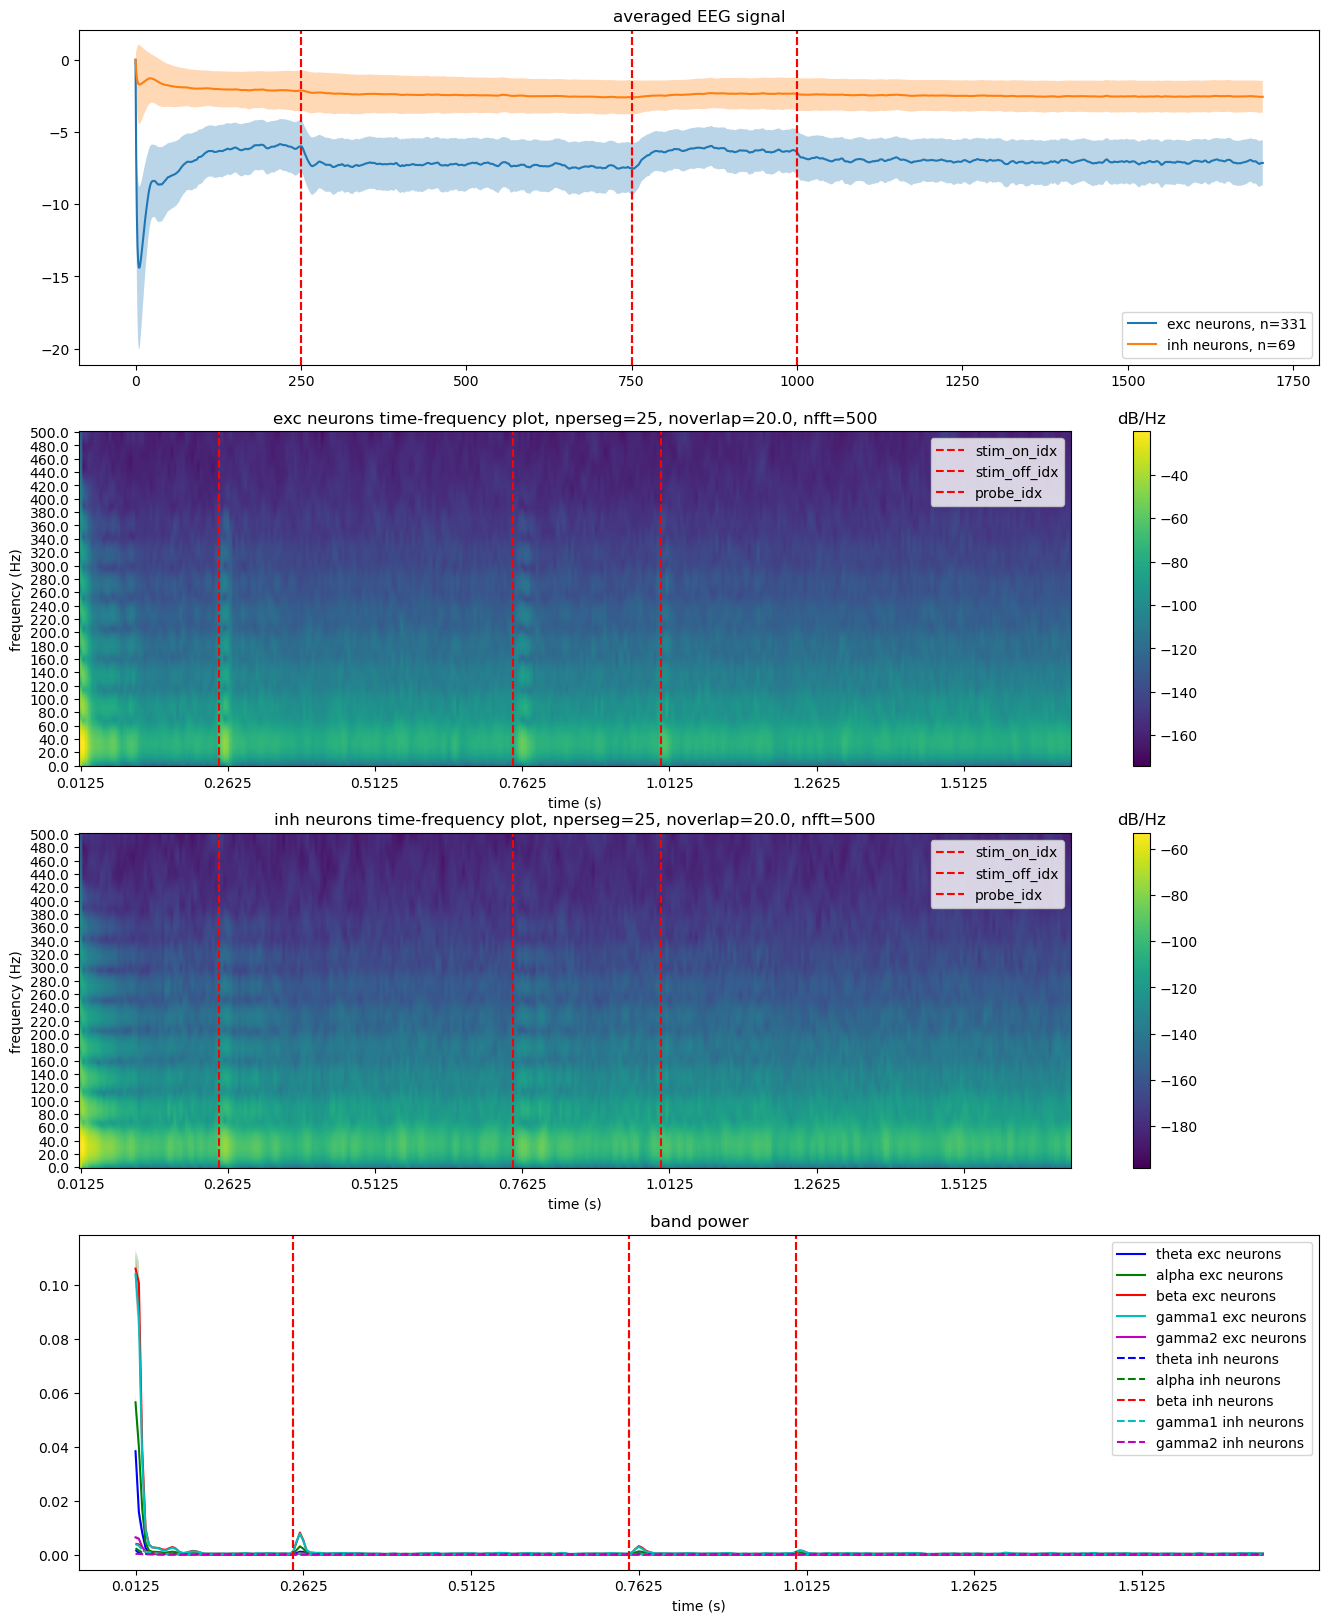

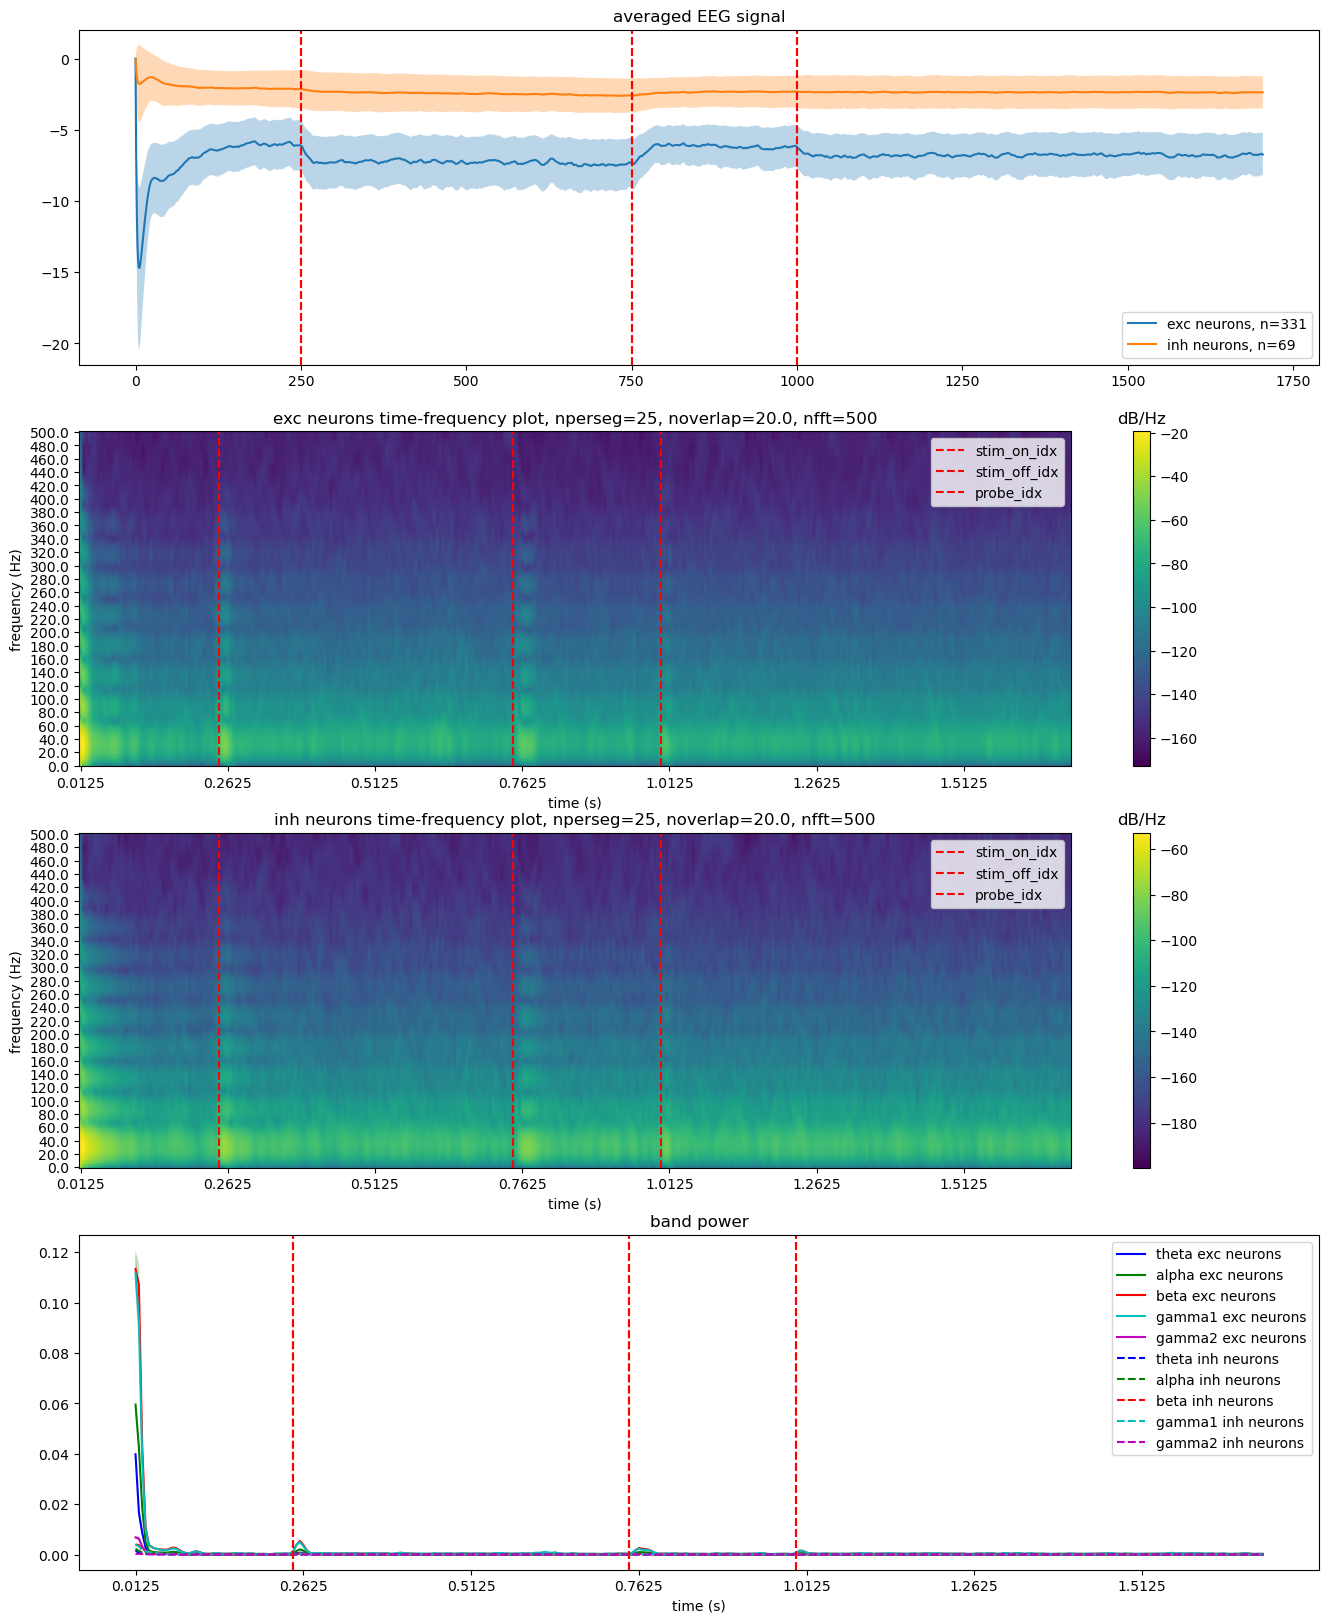

In [ ]:
# plot spects

f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=1, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                            f_cutoff=0, plot=1, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                            t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                            EEG_range = [], spect_range = [], band_range = [])

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)


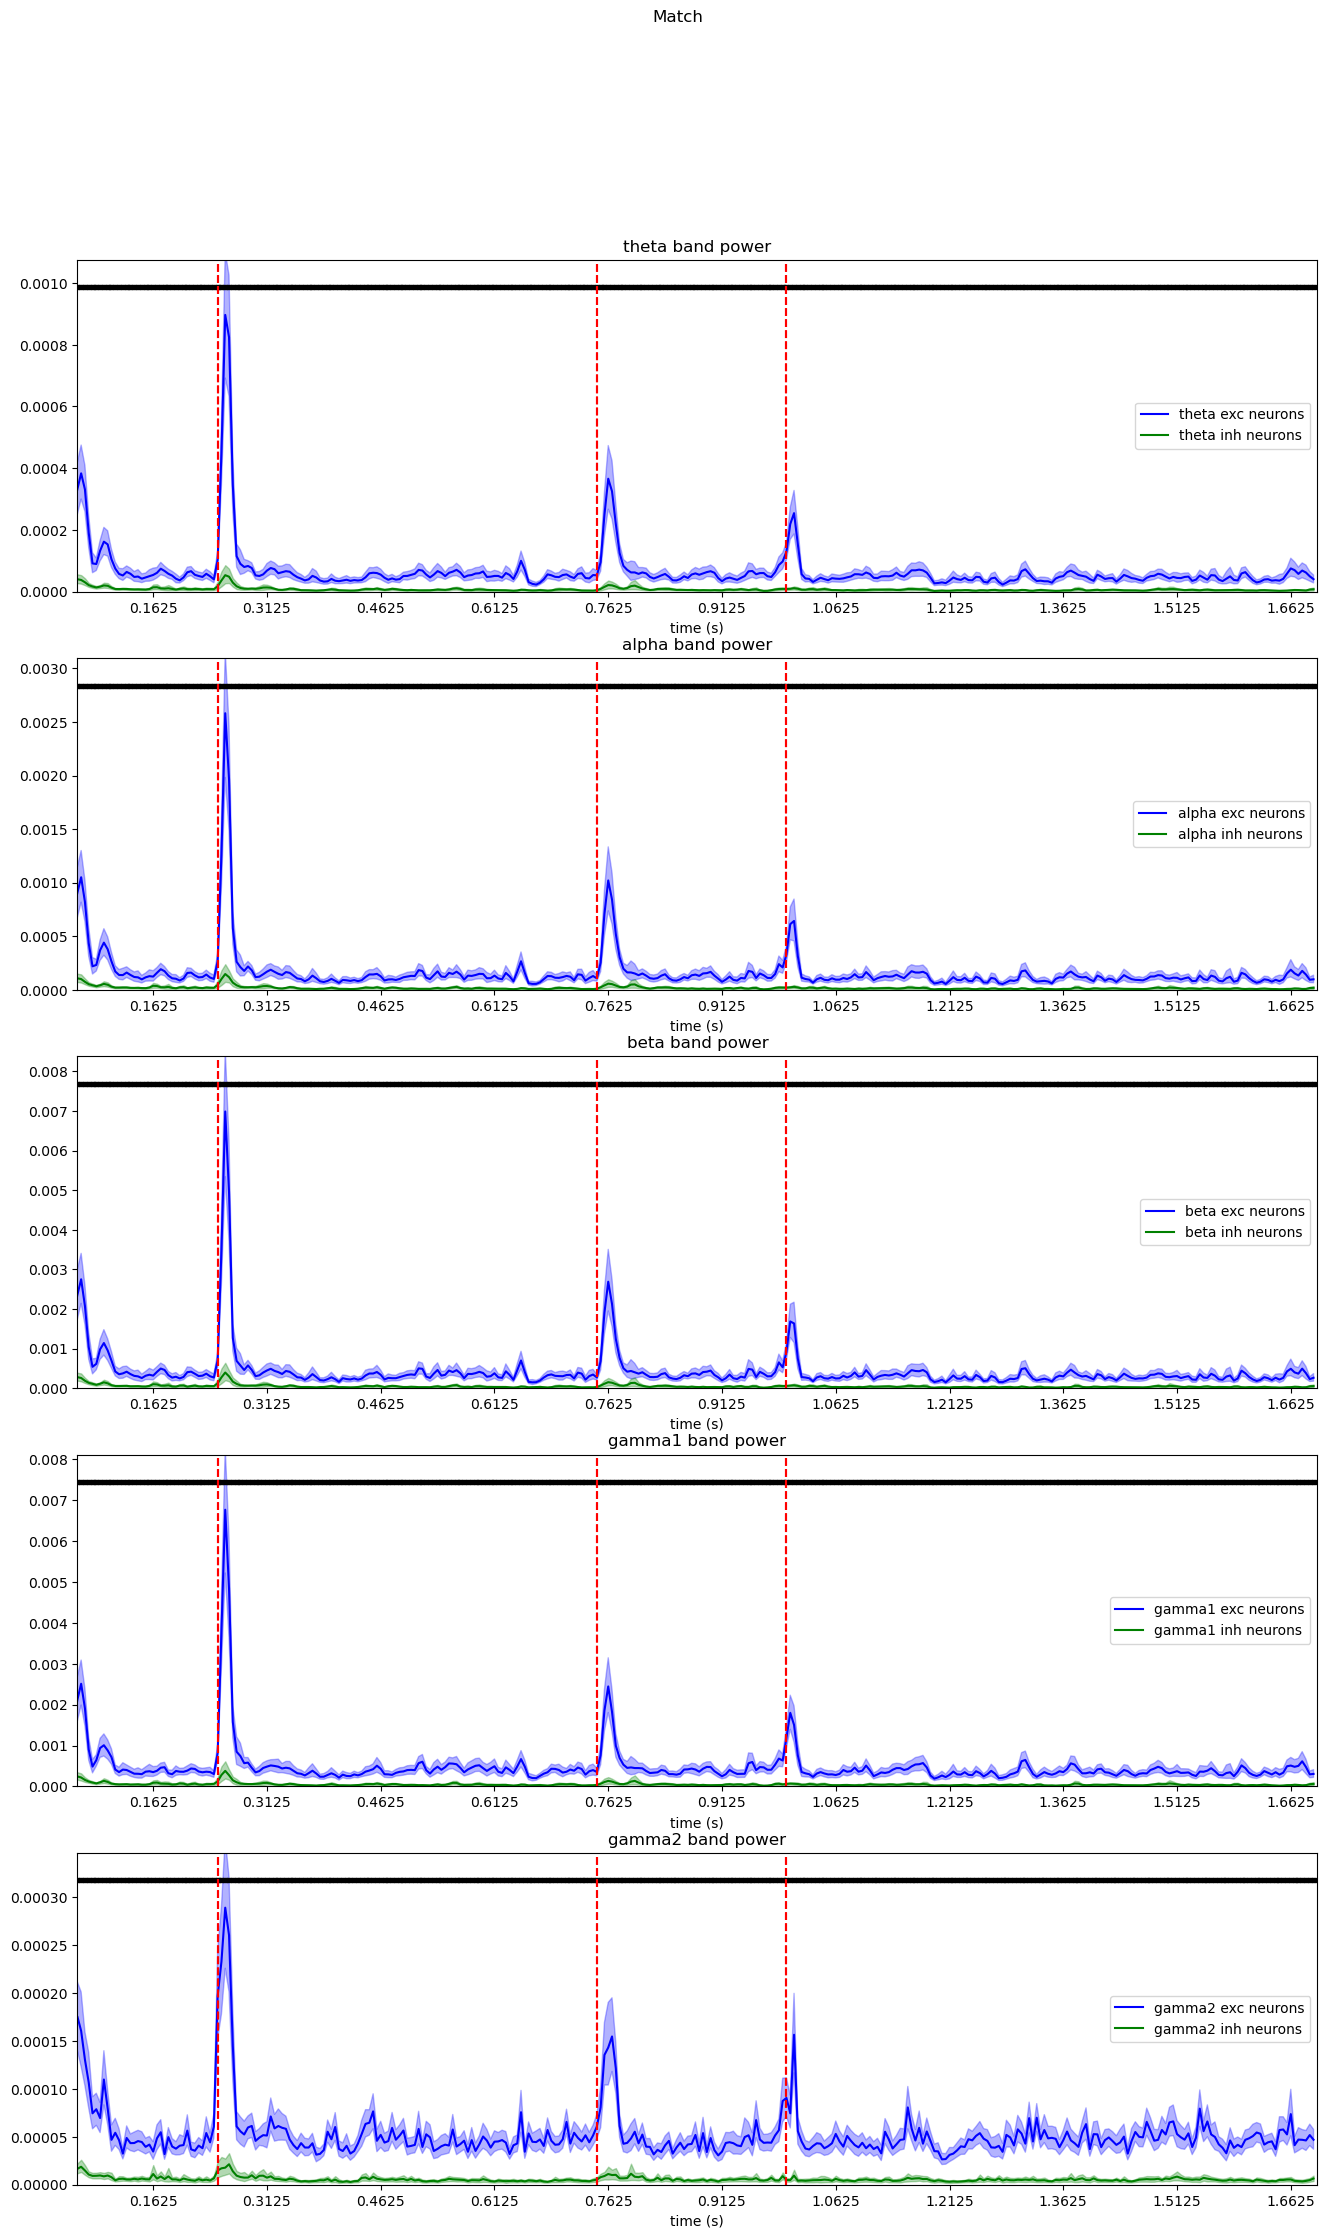

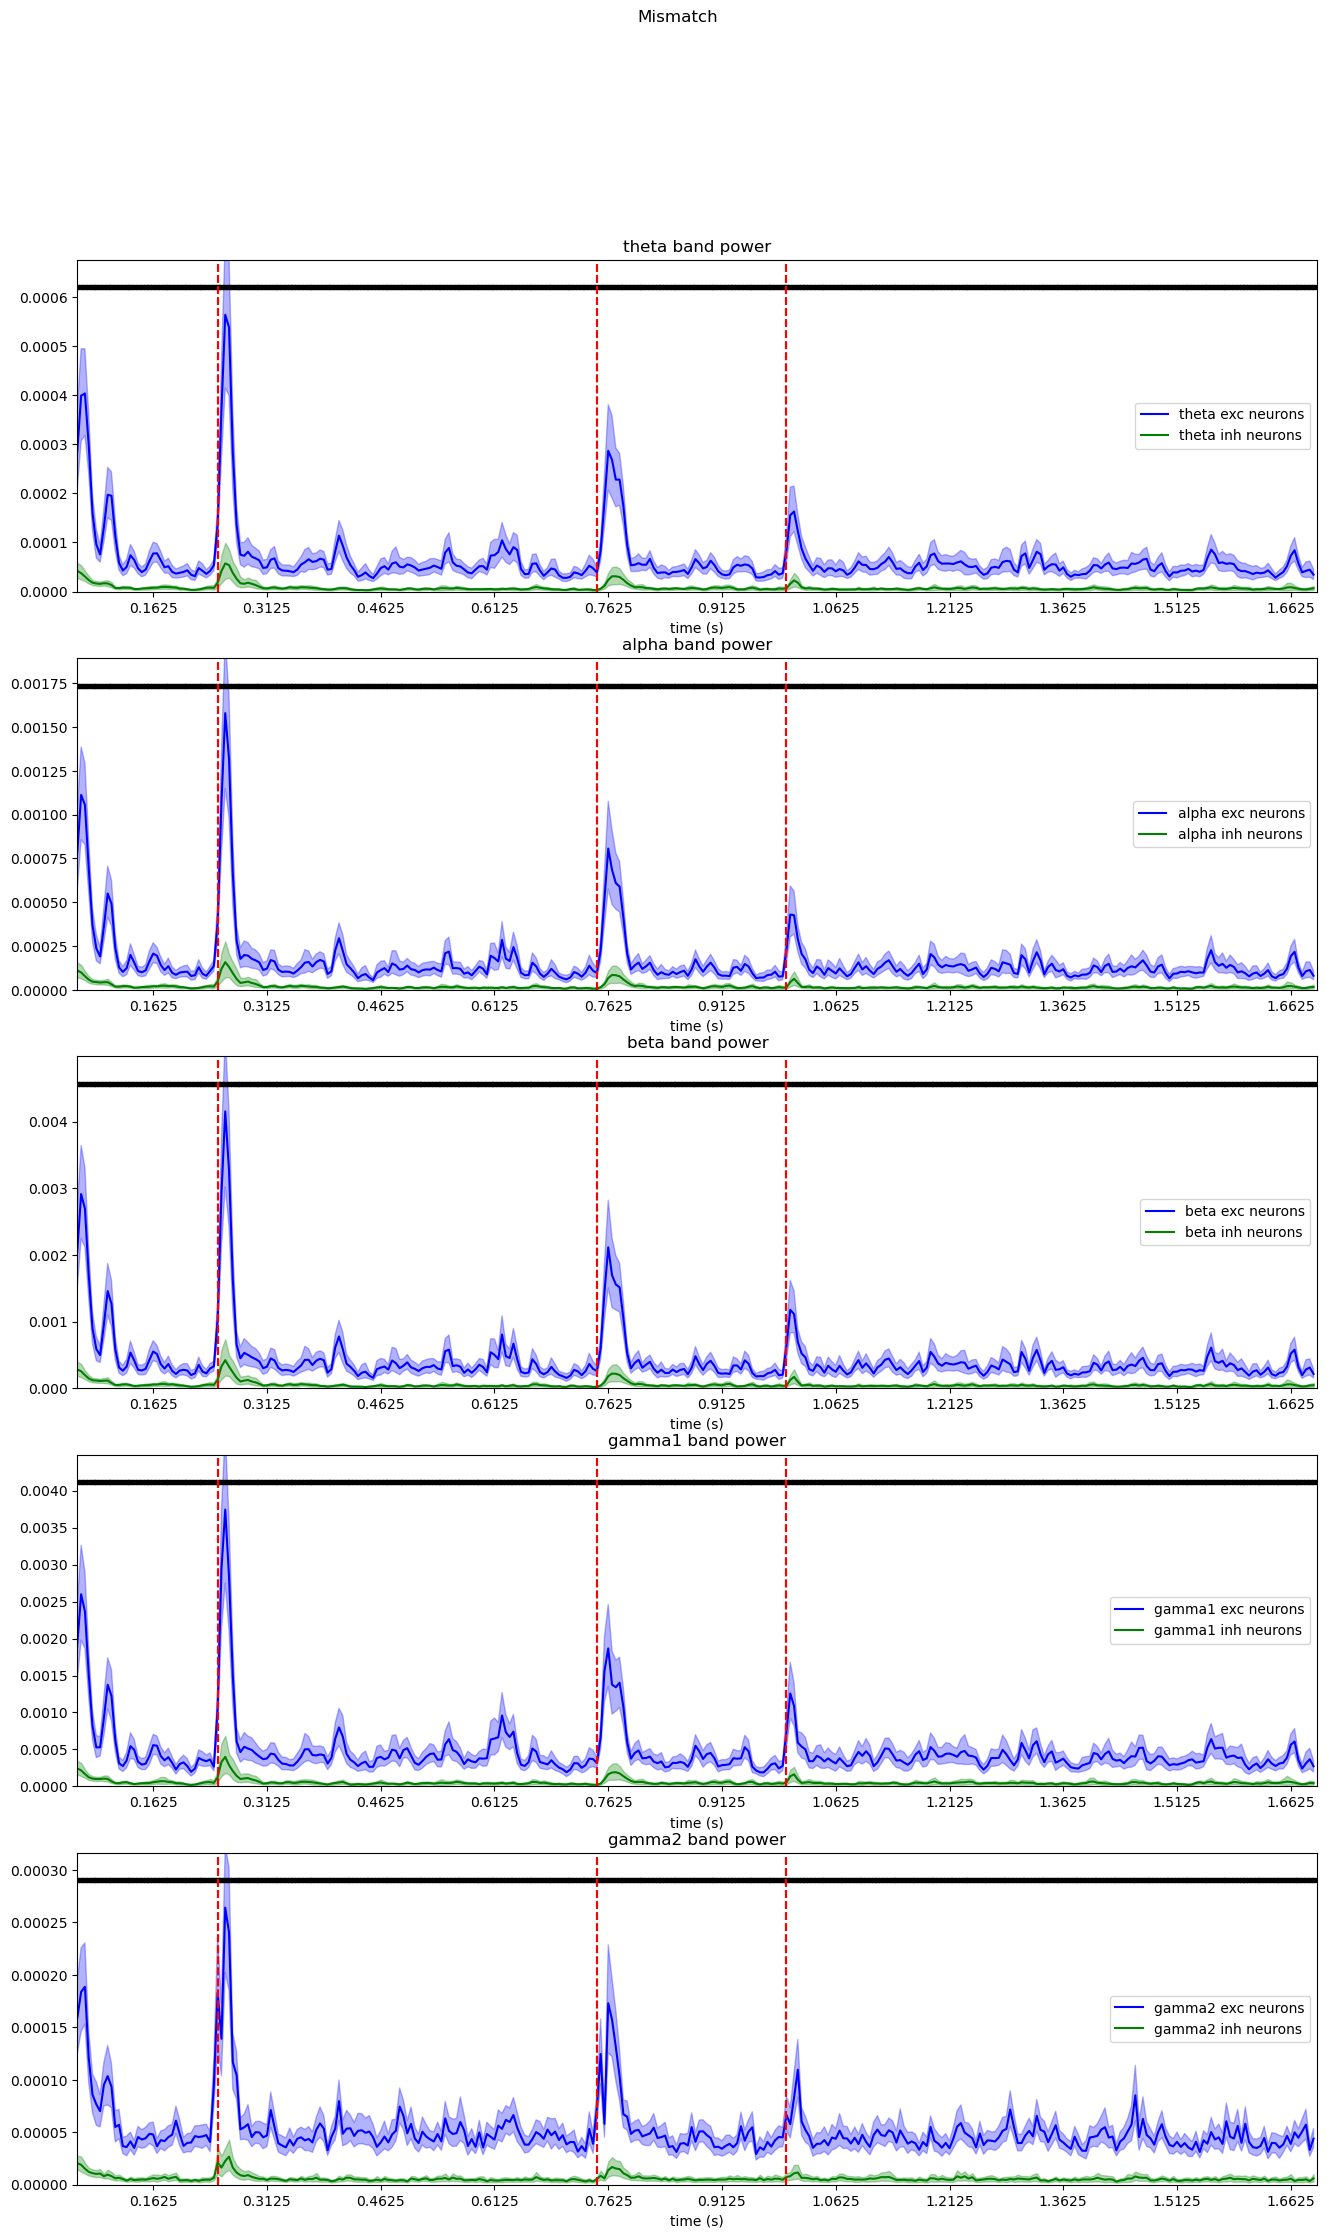

In [ ]:
# plot match and mismatch separately, exc/inh together

importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_match[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Match',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_mismatch[exc_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Mismatch',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

    
    break
    
    

In [9]:
print(f'Avg acc for match: {np.mean(perf[labels == 1])}')
print(f'Avg acc for mismatch: {np.mean(perf[labels == -1])}')

Avg acc for match: 0.92
Avg acc for mismatch: 0.78


Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)


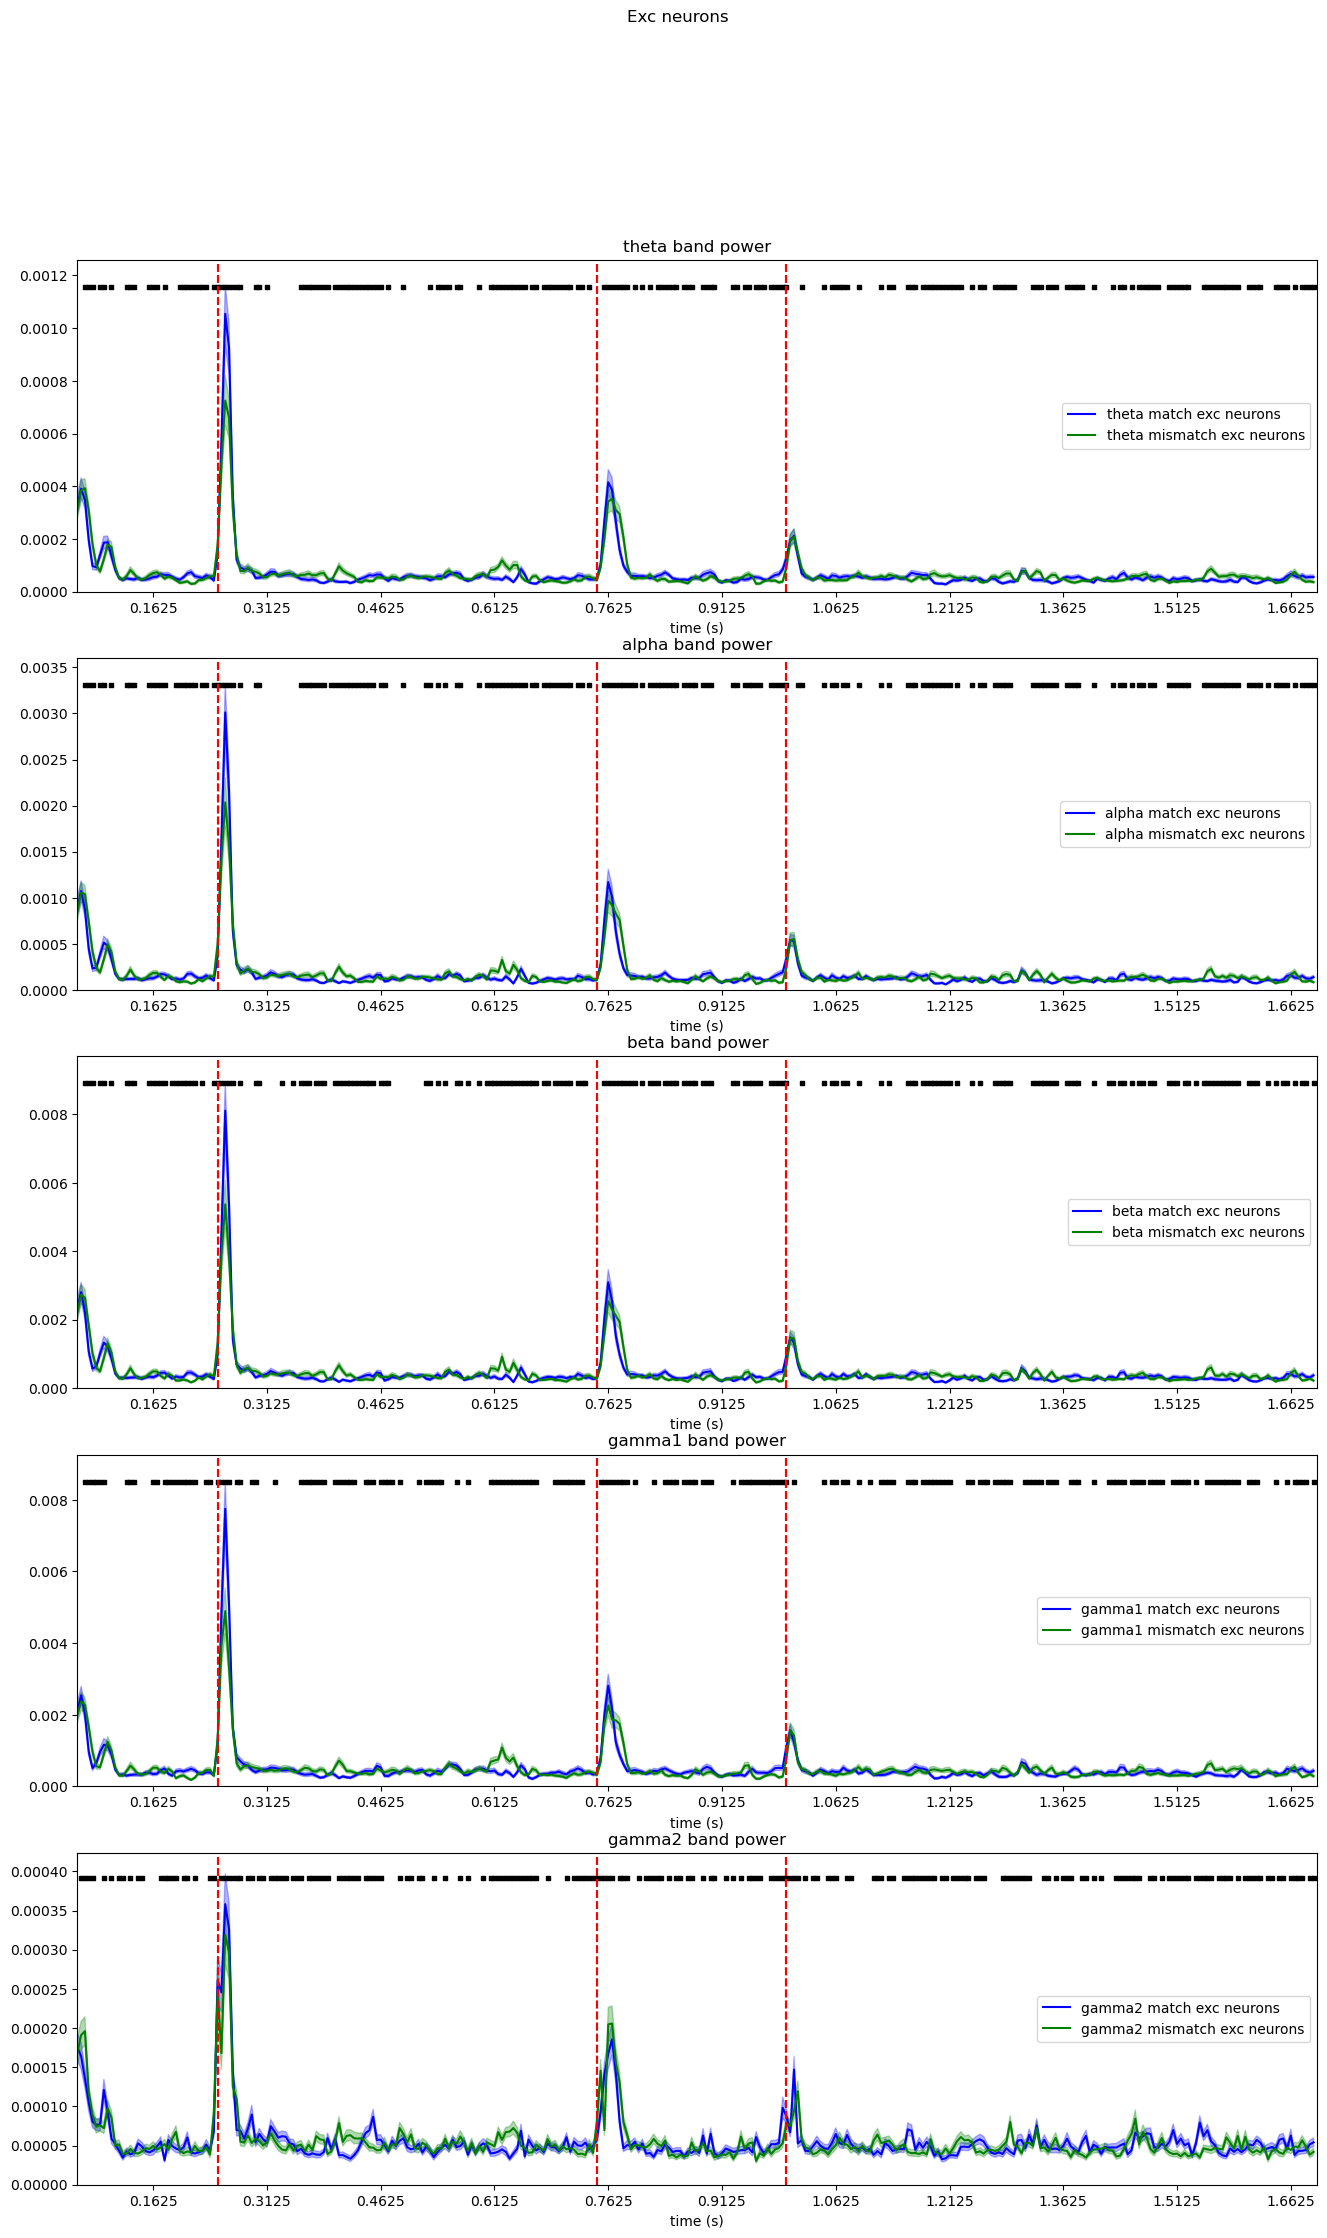

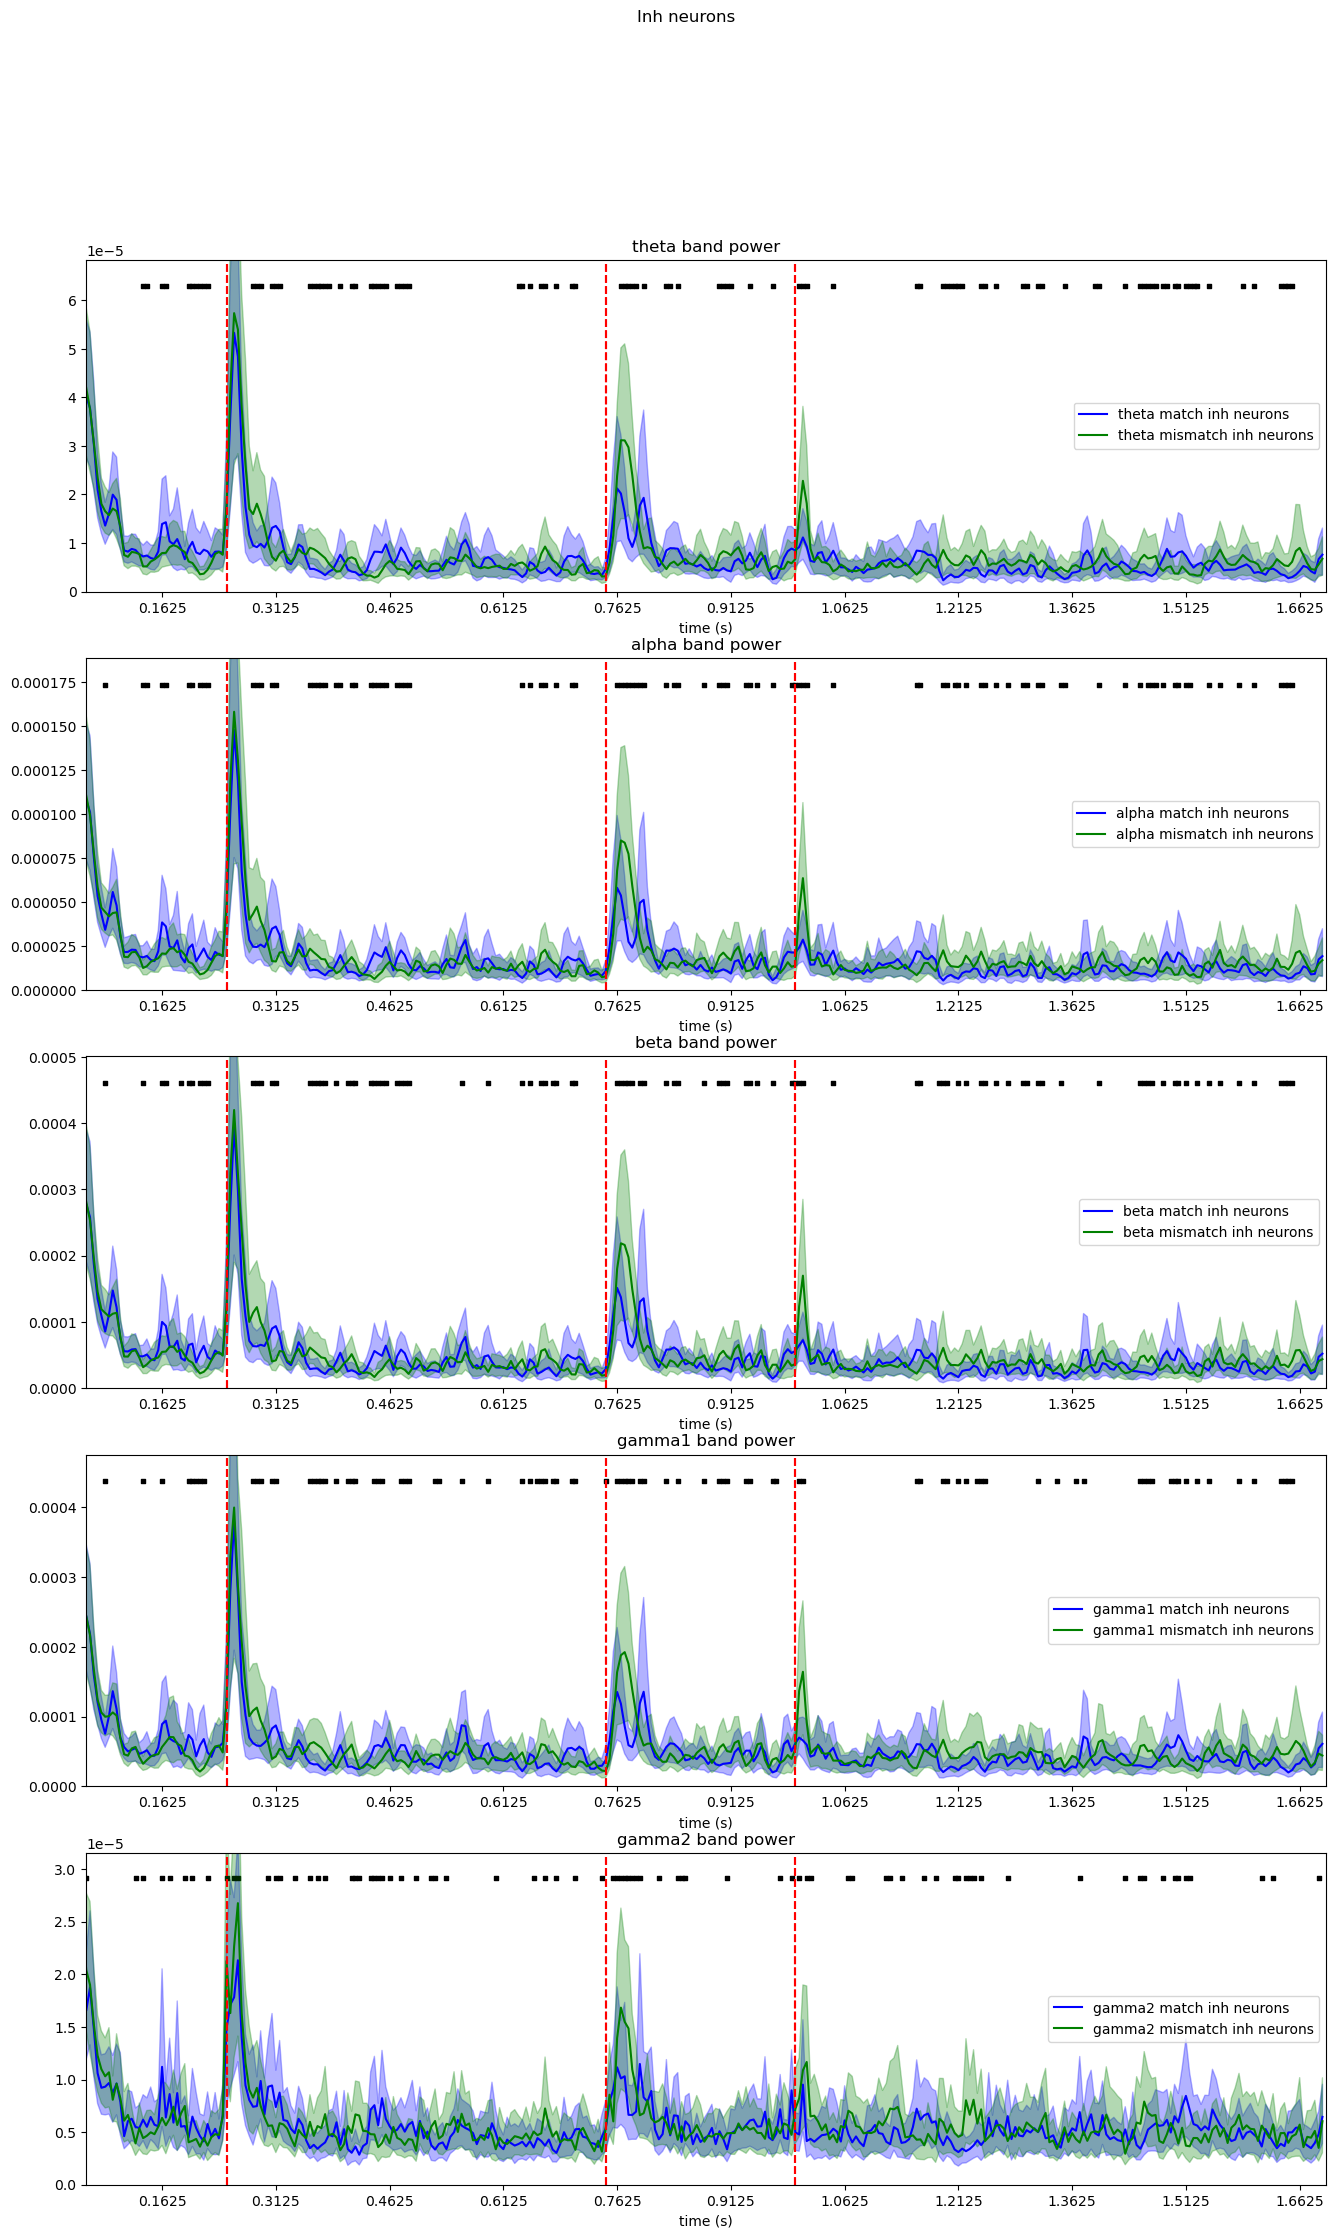

In [7]:
# plot all matches and mismatches on the same plot


importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_mismatch[exc_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='match exc neurons', neur2_label='mismatch exc neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Exc neurons',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[inh_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='match inh neurons', neur2_label='mismatch inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Inh neurons',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

    
    break
    
    

### For this one model, adjust spect params

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)


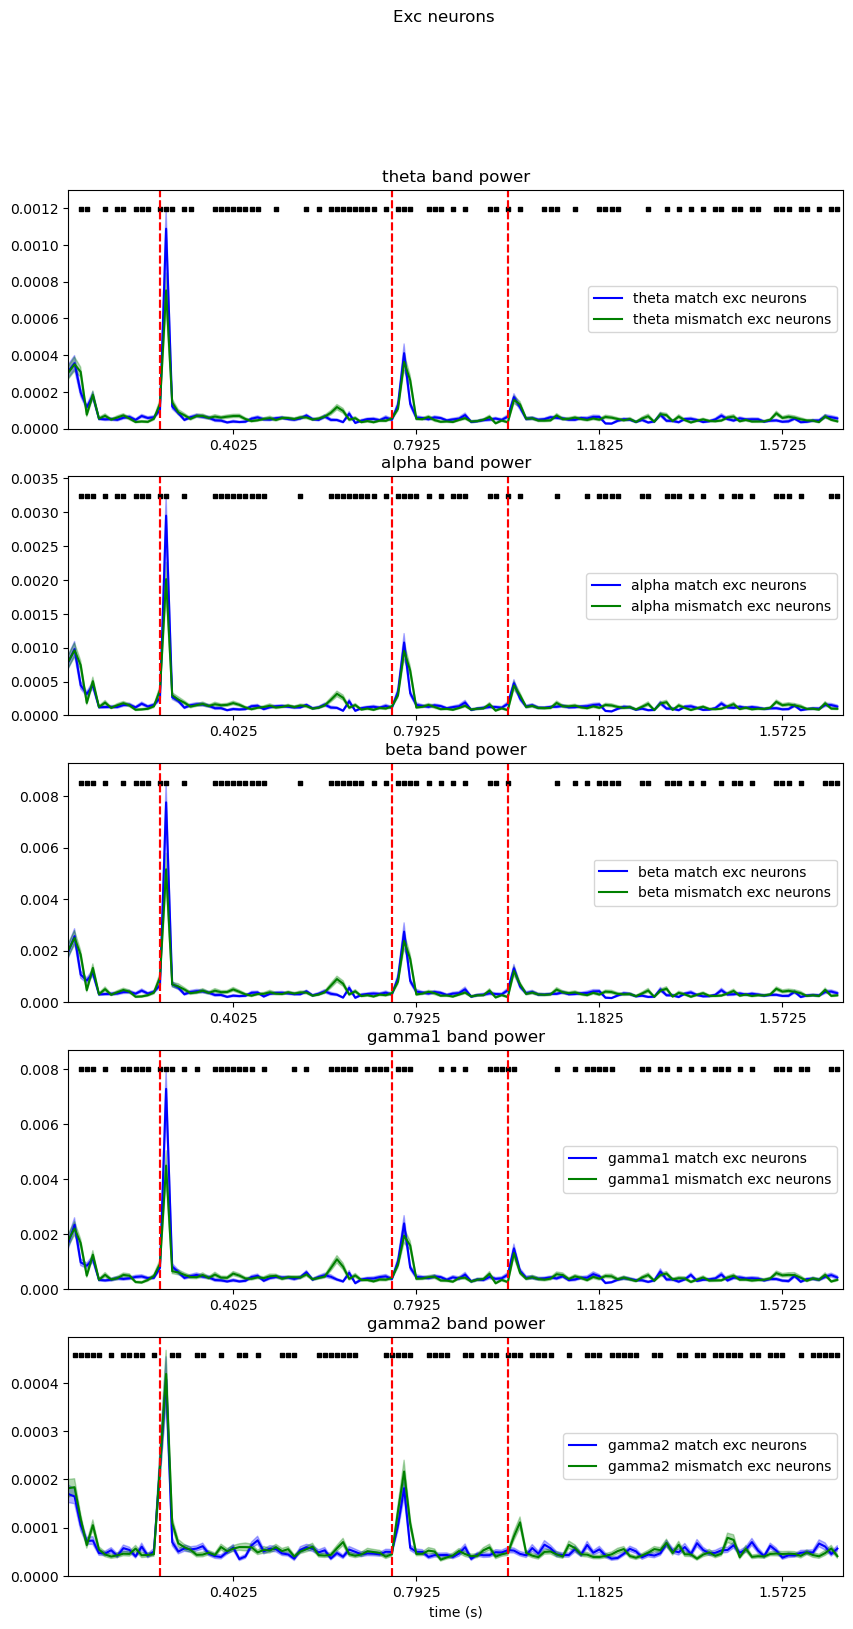

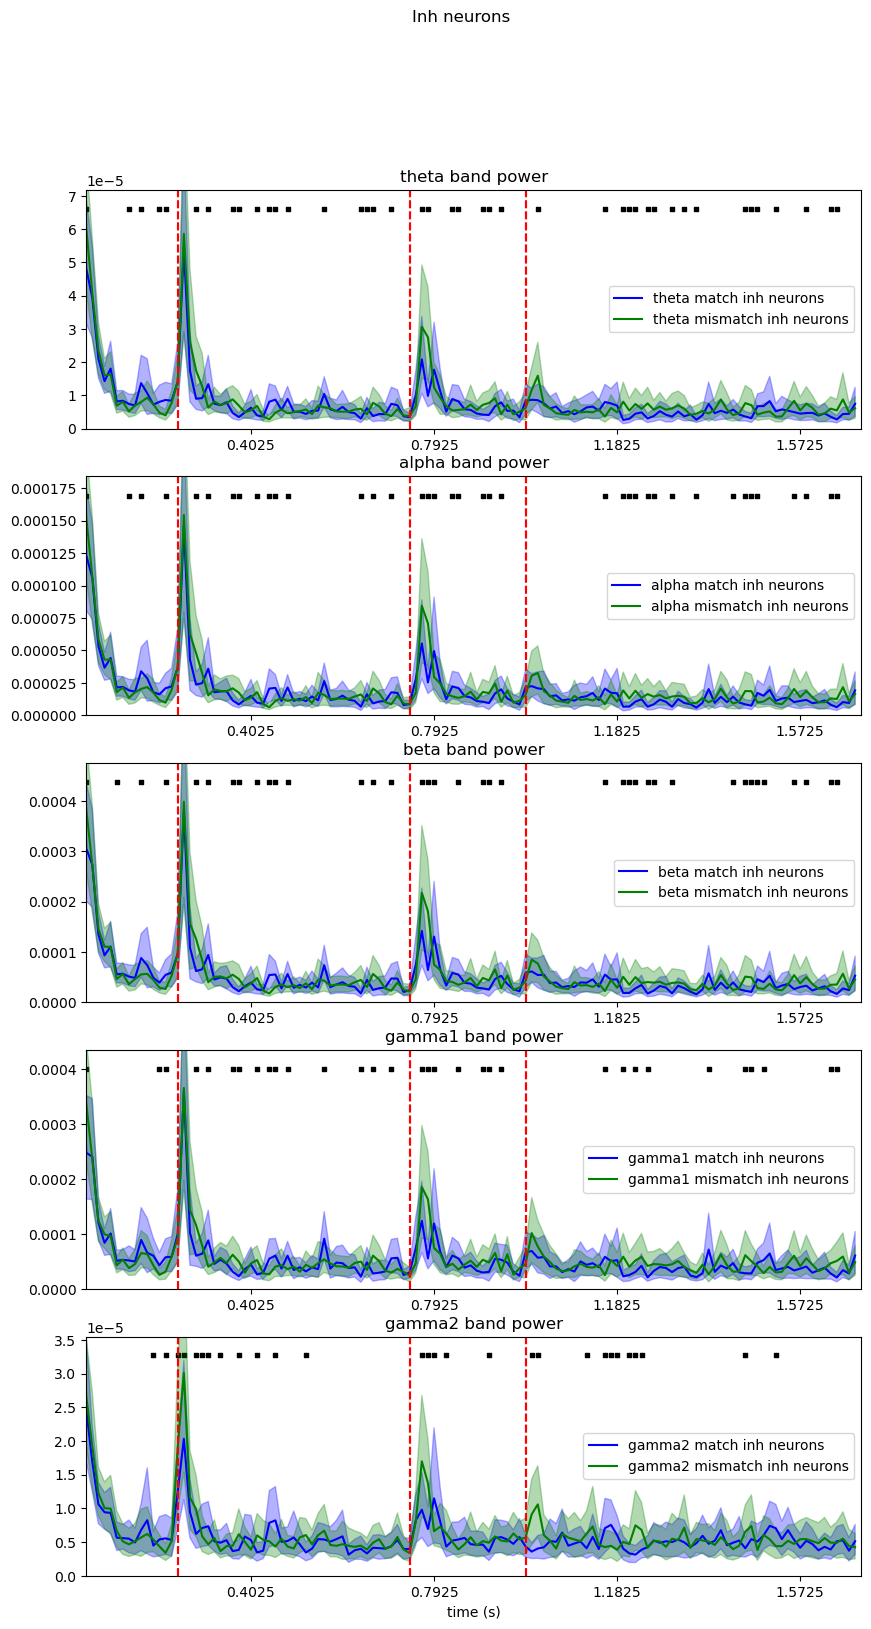

In [4]:
# plot all matches and mismatches on the same plot


importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_mismatch[exc_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='match exc neurons', neur2_label='mismatch exc neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Exc neurons',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[inh_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='match inh neurons', neur2_label='mismatch inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Inh neurons',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

    
    break
    
    

### Now plot a few models

In [5]:
task_load = 2
n_neurons = 400
delay = 50

proj_dir = '/home/nuttidalab/Documents/spikeRNN/'
ipsc_dir = proj_dir + f'models/letters/load_{task_load}/IPSCs/'
model_dir = proj_dir + f'models/letters/load_{task_load}/'

# get all model IPSC files and model files
model_fnames = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(f'Found {len(model_fnames)} model files')

Found 30 model files


In [6]:
print(f'Avg acc for match: {np.mean(perf[labels == 1])}')
print(f'Avg acc for mismatch: {np.mean(perf[labels == -1])}')

Avg acc for match: 0.92
Avg acc for mismatch: 0.78


In [ ]:
# plot all matches and mismatches on the same plot


importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    print(f'Avg acc for match: {np.mean(perf[labels == 1])}')
    print(f'Avg acc for mismatch: {np.mean(perf[labels == -1])}')

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_mismatch[exc_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='match exc neurons', neur2_label='mismatch exc neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title=[],
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[inh_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='match inh neurons', neur2_label='mismatch inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title=[],
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

    
    if i == 4:
        break
    
    

### Now plot avg across models

In [2]:
task_load = 2
n_neurons = 400
delay = 50

proj_dir = '/home/nuttidalab/Documents/spikeRNN/'
ipsc_dir = proj_dir + f'models/letters/load_{task_load}/IPSCs/'
model_dir = proj_dir + f'models/letters/load_{task_load}/'

# get all model IPSC files and model files
model_fnames = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(f'Found {len(model_fnames)} model files')

Found 30 model files


In [3]:
# get correct and incorrect trials

importlib.reload(su)

s_match_all_exc = []
s_match_all_inh = []
s_mismatch_all_exc = []
s_mismatch_all_inh = []
perf_match_all = np.zeros(len(model_fnames))
perf_mismatch_all = np.zeros(len(model_fnames))
for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    correct_idx = np.where(perf == 1)[0]
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    # match & mismatch, all
    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    s_match_all_exc.append(np.nanmean(s_match[exc_ind,:,:],axis=0))
    s_match_all_inh.append(np.nanmean(s_match[inh_ind,:,:],axis=0))
    s_mismatch_all_exc.append(np.nanmean(s_mismatch[exc_ind,:,:],axis=0))
    s_mismatch_all_inh.append(np.nanmean(s_mismatch[inh_ind,:,:],axis=0))

    perf_match_all[i] = np.mean(perf[labels == 1])
    perf_mismatch_all[i] = np.mean(perf[labels == -1])

s_match_all_exc = np.array(s_match_all_exc)
s_match_all_inh = np.array(s_match_all_inh)
s_mismatch_all_exc = np.array(s_mismatch_all_exc)
s_mismatch_all_inh = np.array(s_mismatch_all_inh)

print(s_match_all_exc.shape)
print(s_match_all_inh.shape)
print(s_mismatch_all_exc.shape)
print(s_mismatch_all_inh.shape)

print(f'Avg acc for match: {np.mean(perf_match_all)}')
print(f'Avg acc for mismatch: {np.mean(perf_mismatch_all)}')

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_041857.mat (2/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_013258.mat (3/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_220838.mat (4/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_010607.mat (5/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_034726.mat (6/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_231248.mat (7/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_004941.mat (8/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_032728.mat (9/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_020259.mat (10/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_024650.mat (11/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12

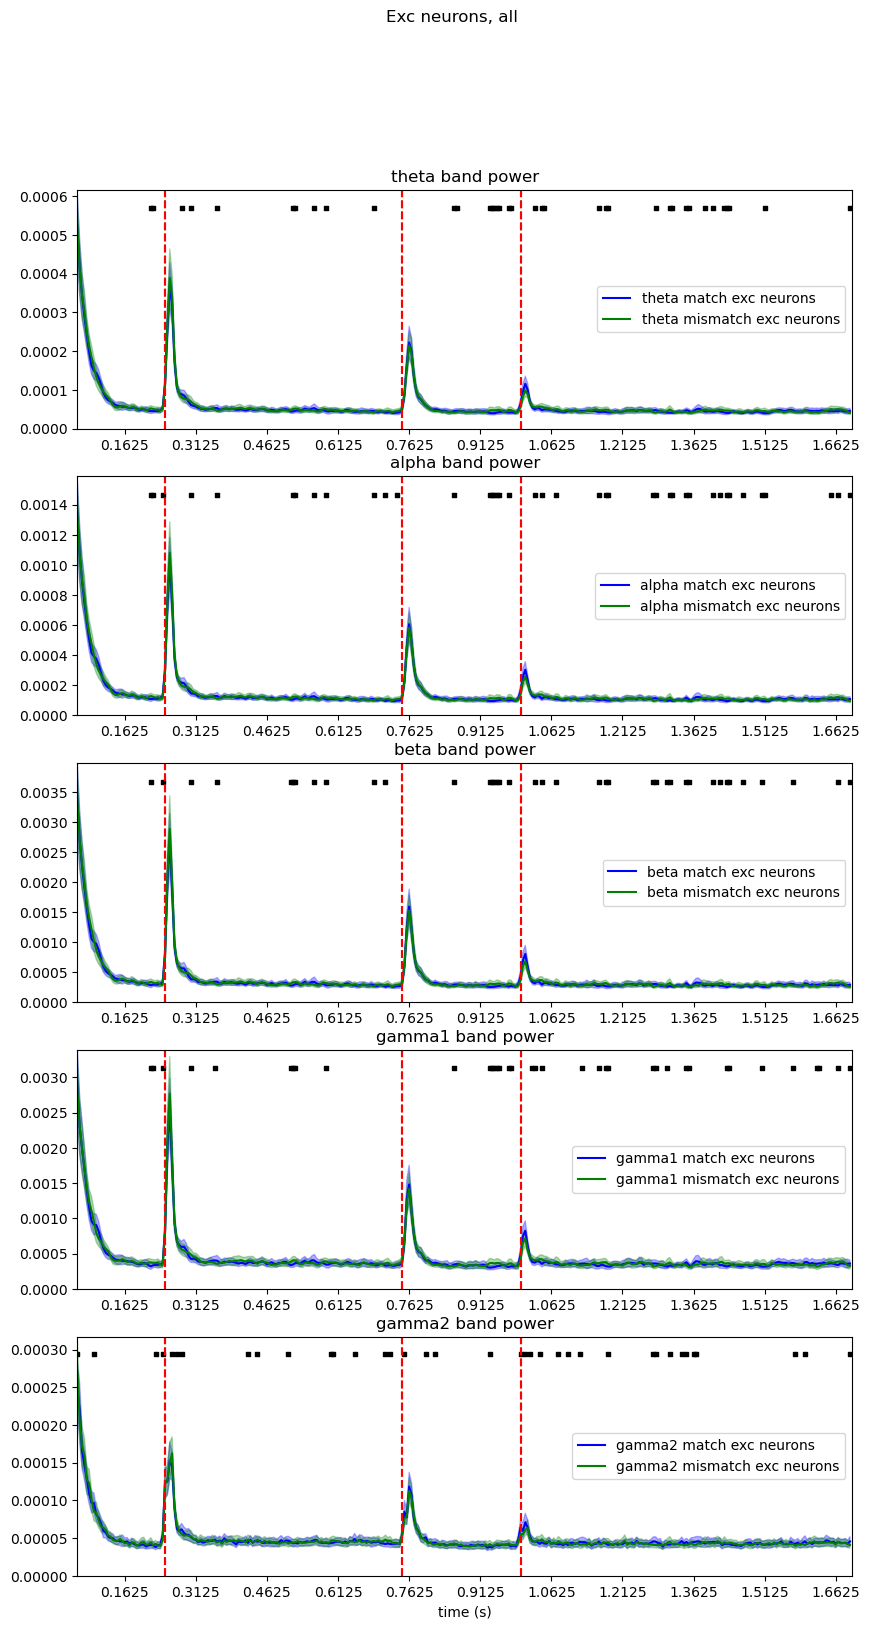

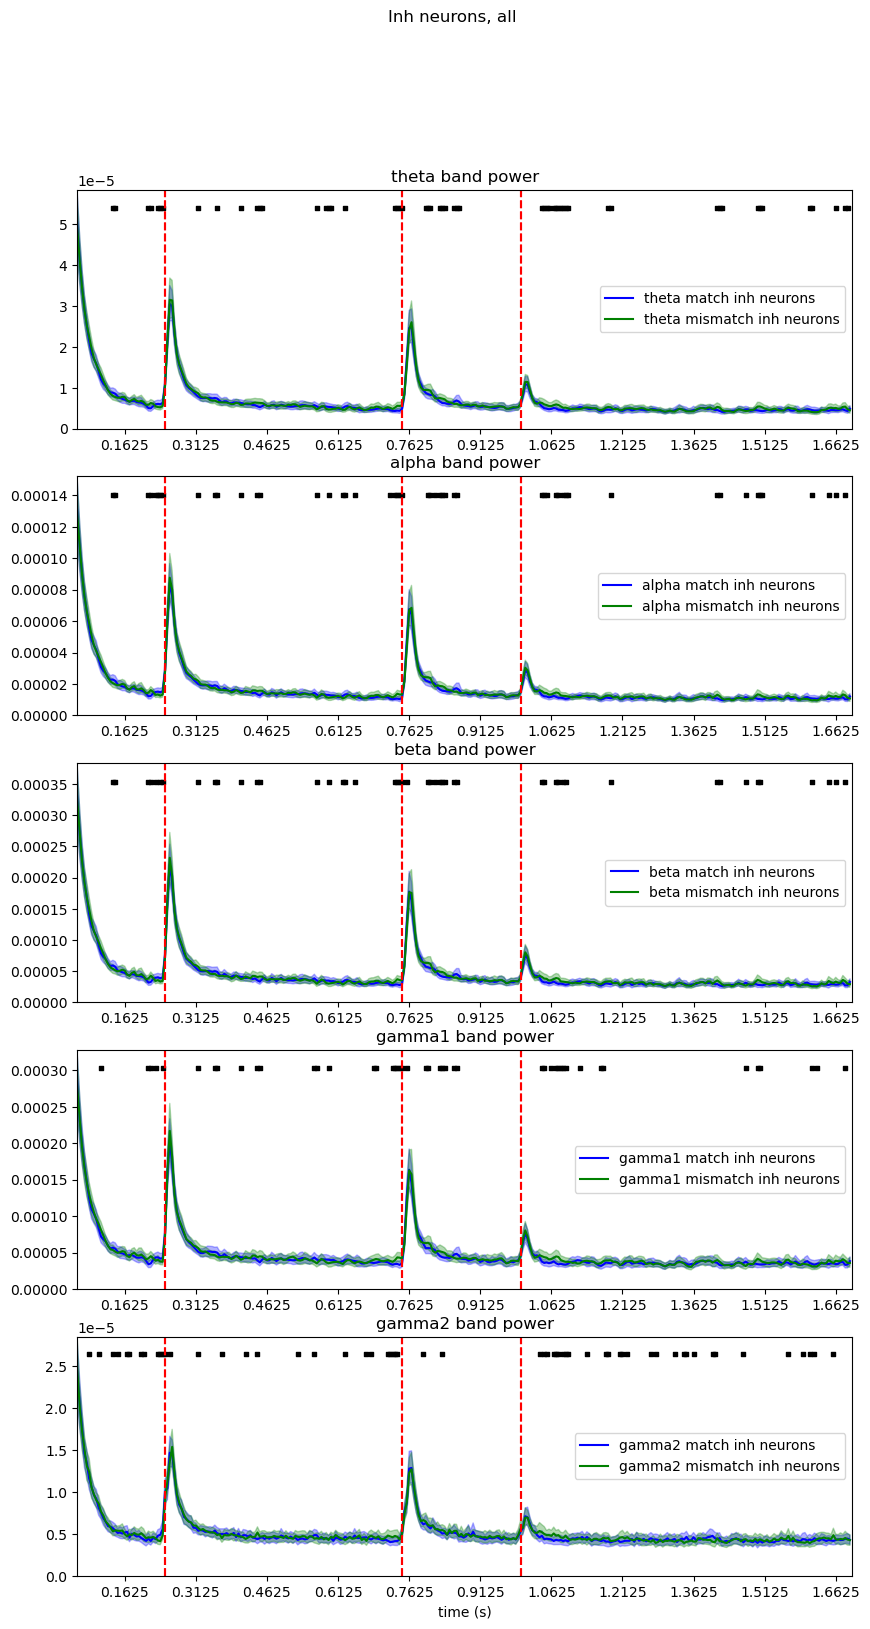

In [4]:
# get bootstrap confidence intervals
band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match_all_exc, s_mismatch_all_exc,
                stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                t_skip=30, f_skip=10, neur1_label='match exc neurons', neur2_label='mismatch exc neurons',
                nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Exc neurons, all',
                p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match_all_inh, s_mismatch_all_inh,
                stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                t_skip=30, f_skip=10, neur1_label='match inh neurons', neur2_label='mismatch inh neurons',
                nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Inh neurons, all',
                p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

In [6]:
print(f'match, correct: {np.where((labels == 1) & (perf == 1))[0].shape}')
print(f'match, incorrect: {np.where((labels == 1) & (perf == 0))[0].shape}')
print(f'mismatch, correct: {np.where((labels == -1) & (perf == 1))[0].shape}')
print(f'mismatch, incorrect: {np.where((labels == -1) & (perf == 0))[0].shape}')

match, correct: (49,)
match, incorrect: (1,)
mismatch, correct: (48,)
mismatch, incorrect: (2,)


## Across models

### Are models biased for match or mismatch?

In [3]:
# get performance in match and mismatch trials for all models

# get all model IPSC files and model files
match_perf = []
mismatch_perf = []
for i, model_fname in enumerate(model_fnames):
    # print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])

    match_perf.append(np.nanmean(perf[labels == 1]))
    mismatch_perf.append(np.nanmean(perf[labels == -1]))

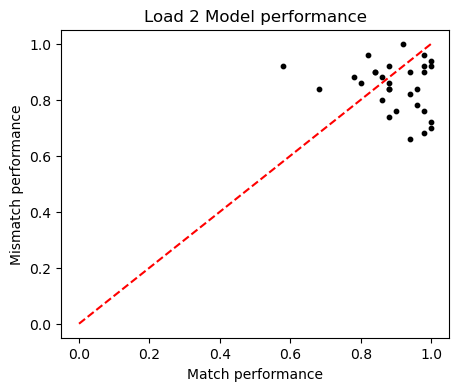

In [5]:
plt.figure(figsize=(5,4))
plt.scatter(match_perf, mismatch_perf, s=10, c='k')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Match performance')
plt.ylabel('Mismatch performance')
plt.title('Load 2 Model performance')
plt.show()